# Credit Risk PD Model — Development & Validation
### German Credit Data (kabure / UCI)

This notebook walks through data loading, EDA, PD model development (Logistic
Regression), and challenger benchmarking (XGBoost), mirroring the modular code
in `src/`. See `reports/validation_report.md` for the full written validation
report; this notebook is the exploratory/modelling companion.

In [1]:
import os, sys

# Ensure paths resolve to the project root regardless of where Jupyter is launched from
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, 'src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option('display.max_columns', 50)
print('Working directory:', os.getcwd())

Working directory: /home/claude/credit-risk-pd-model


## 1. Data loading & quality checks

In [2]:
from data_prep import load_raw, clean, add_target

df_raw = load_raw()
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
print('Missing values:')
print(df_raw.isnull().sum())
print('\nDuplicates:', df_raw.duplicated().sum())

Missing values:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Duplicates: 0


**Note on missing values**: `Saving accounts` (183 missing) and `Checking account`
(394 missing) are not randomly missing — a blank means the customer holds no
account of that type. We encode this explicitly as a `'none'` category rather
than imputing, so we don't invent an account status that doesn't exist.

In [4]:
df = clean(df_raw)
df = add_target(df)
print(df['Risk'].value_counts())
print(df['Risk'].value_counts(normalize=True).round(3))

Risk
good    700
bad     300
Name: count, dtype: int64
Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64


Target is 70% good / 30% bad — a mild imbalance that we preserve (see modelling section) rather than artificially rebalance.

## 2. EDA — key visualizations

In [5]:
from eda import run_eda
summary = run_eda()
summary

/home/claude/credit-risk-pd-model/src/eda.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y="Credit amount", ax=axes[0],
/home/claude/credit-risk-pd-model/src/eda.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y="Duration", ax=axes[1],


{'n_rows': 1000,
 'n_duplicates': 0,
 'missing_savings_pct': 0.183,
 'default_rate_overall': 0.3,
 'default_rate_no_checking': 0.116751269035533,
 'default_rate_rich_checking': 0.2222222222222222,
 'age_mean_good': 36.22428571428571,
 'age_mean_bad': 33.96333333333333,
 'credit_amount_mean_good': 2985.457142857143,
 'credit_amount_mean_bad': 3938.1266666666666,
 'duration_mean_good': 19.207142857142856,
 'duration_mean_bad': 24.86}

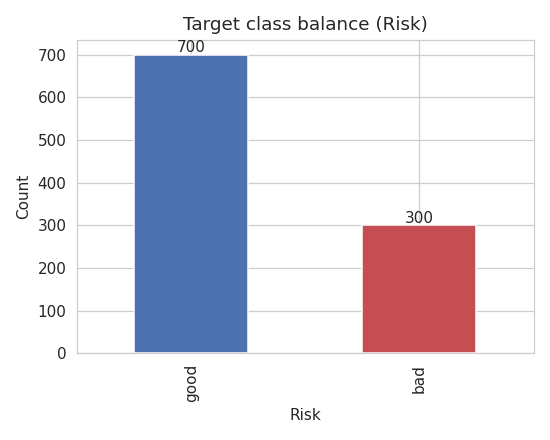

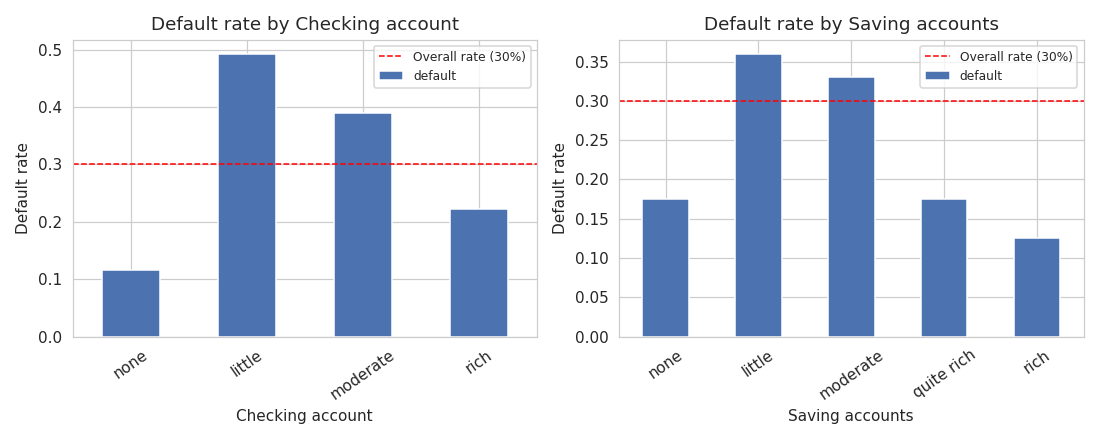

In [6]:
display(Image('reports/figures/01_target_balance.png'))
display(Image('reports/figures/02_default_by_account_status.png'))

**Key EDA finding**: default rate by `Checking account` is **non-monotonic**
(none=11.7% → little=49.3% → moderate=39.0% → rich=22.2%). Customers with *no*
checking account default *less* than those with a *little* money in one. This
matters for modelling: an ordinal encoding (none < little < moderate < rich)
assumes a monotonic relationship that does not hold in the data, and we
revisit this directly when interpreting the Logistic Regression coefficients
below.

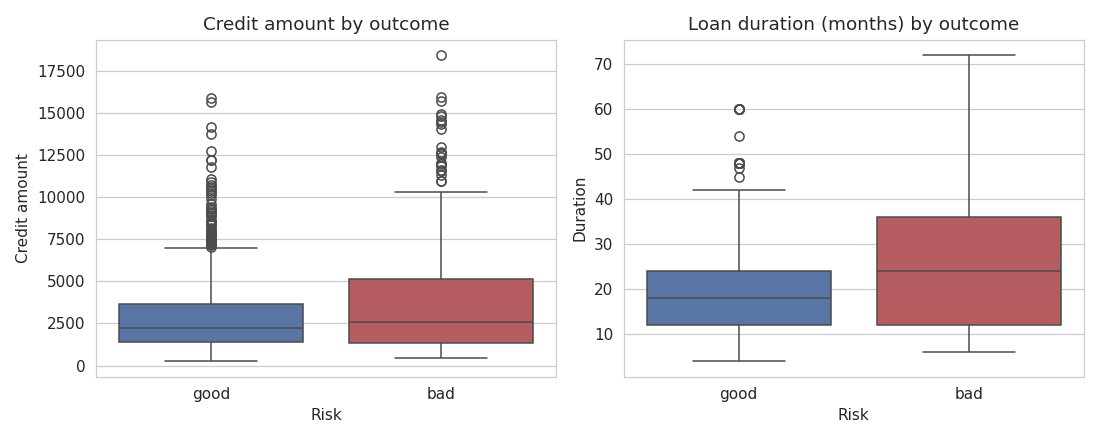

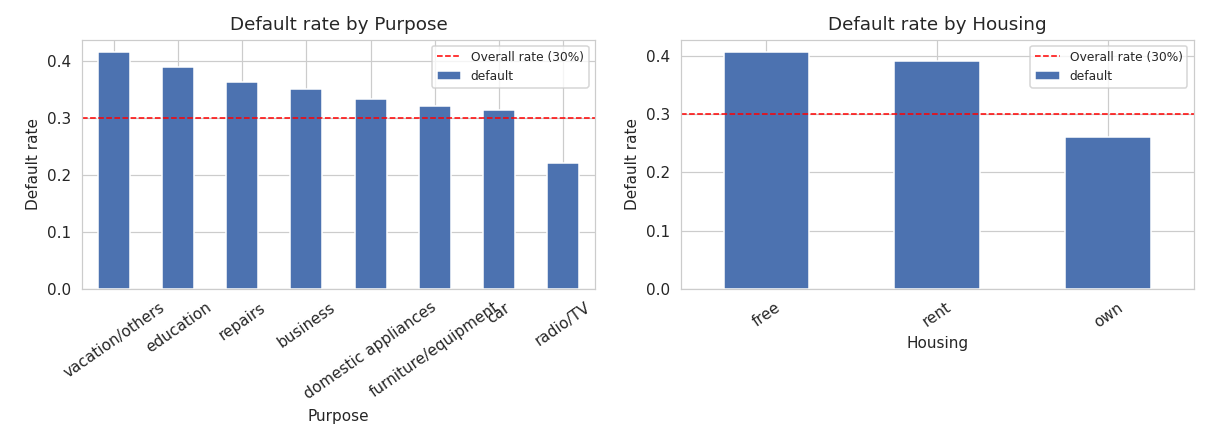

In [7]:
display(Image('reports/figures/03_amount_duration_by_risk.png'))
display(Image('reports/figures/04_default_by_purpose_housing.png'))

Bad loans skew toward higher credit amounts and longer durations, and 'housing=free' / higher-risk purposes (vacation, education) show elevated default rates — all directionally sensible.

## 3. Data preparation & train/test split

In [8]:
from modeling import get_splits

X_train, X_test, y_train, y_test = get_splits()
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train default rate:', y_train.mean().round(3), ' Test default rate:', y_test.mean().round(3))
X_train.head()

Train: (750, 16)  Test: (250, 16)
Train default rate: 0.3  Test default rate: 0.3


,Age,Job,Credit amount,Duration,Saving accounts_ord,Checking account_ord,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
350,23,2,1236,9,1,0,0,0,1,0,1,0,0,0,0,0
0,67,2,1169,6,0,1,1,1,0,0,0,0,0,1,0,0
637,21,2,15653,60,1,0,1,1,0,0,0,0,0,1,0,0
341,26,1,3599,21,1,1,0,0,1,0,0,0,1,0,0,0
626,41,2,2116,6,1,3,1,1,0,0,0,0,1,0,0,0


**Class imbalance approach**: 70/30 is a mild imbalance reflecting a real
default rate. We deliberately do **not** apply SMOTE/oversampling — resampling
would distort the class prior and bias predicted probabilities away from the
true population rate, which matters for a PD model whose output feeds
expected-loss calculations. Instead we stratify the split and pick the
decision threshold deliberately later, rather than defaulting to 0.5.

## 4. Baseline model — Logistic Regression

In [9]:
from modeling import fit_logistic_regression

lr_model, scaler = fit_logistic_regression(X_train, y_train)

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
coef_df

,feature,coefficient
5,Checking account_ord,0.470593
3,Duration,0.444362
11,Purpose_education,0.210562
7,Housing_own,-0.191372
13,Purpose_radio/TV,-0.157088
6,Sex_male,-0.147904
14,Purpose_repairs,0.099931
0,Age,-0.087641
15,Purpose_vacation/others,-0.075069
12,Purpose_furniture/equipment,0.036721


**Interpreting coefficients**: `Checking account_ord` has a *positive*
coefficient — more money in checking associates with *higher* predicted risk
in the linear model. This is a direct consequence of the non-monotonic pattern
noted in EDA: the ordinal encoding forces a straight-line relationship onto a
hump-shaped one, and the model picks up the 'little vs none' jump more than
anything else. **This is a real interpretability flaw a validator should
flag** — the sign is not a usable business explanation ("more savings → more
risk") even though it is mechanically what the data produces under this
encoding. A cleaner treatment (e.g. WOE encoding, or splitting 'none' out as
its own dummy rather than the base of an ordinal scale) would likely fix this
and is noted as a recommendation in the validation report.

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train.astype(float).copy()
X_vif.insert(0, 'const', 1.0)
vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False)

,feature,VIF
10,Purpose_car,3.046008
14,Purpose_radio/TV,2.807555
9,Housing_rent,2.732114
8,Housing_own,2.648781
13,Purpose_furniture/equipment,2.446843
3,Credit amount,1.914682
4,Duration,1.789909
12,Purpose_education,1.549784
15,Purpose_repairs,1.220812
1,Age,1.140360


All VIFs are well under the common concern threshold of 5, so multicollinearity is not a material issue for this feature set.

In [11]:
# Linearity of log-odds check for continuous variables (binned empirical log-odds)
for col in ['Age', 'Credit amount', 'Duration']:
    bins = pd.qcut(df[col], q=5, duplicates='drop')
    grp = df.groupby(bins, observed=True)['default'].mean()
    logodds = np.log(grp / (1 - grp))
    print(f'--- {col} ---')
    print(logodds.round(3))
    print()

--- Age ---
Age
(18.999, 26.0]   -0.440
(26.0, 30.0]     -0.773
(30.0, 36.0]     -1.050
(36.0, 45.0]     -1.035
(45.0, 75.0]     -1.084
Name: default, dtype: float64

--- Credit amount ---
Credit amount
(249.999, 1262.0]   -0.831
(1262.0, 1906.8]    -1.146
(1906.8, 2852.4]    -0.995
(2852.4, 4720.0]    -1.046
(4720.0, 18424.0]   -0.302
Name: default, dtype: float64

--- Duration ---
Duration
(3.999, 12.0]   -1.315
(12.0, 15.0]    -1.513
(15.0, 24.0]    -0.747
(24.0, 30.0]    -0.693
(30.0, 72.0]    -0.081
Name: default, dtype: float64



`Age` and `Duration` show reasonably monotonic log-odds trends (roughly
linear). `Credit amount` shows a non-monotonic, U-shaped pattern — its
near-zero coefficient (-0.007) in the LR model likely reflects that a single
linear term cannot capture this shape well, rather than the variable being
truly uninformative. Flagged as a limitation.

## 5. Challenger model — XGBoost

In [12]:
from modeling import fit_xgboost

xgb_model = fit_xgboost(X_train, y_train)
print('XGBoost fit with modest, documented hyperparameters:')
print(xgb_model.get_params())

XGBoost fit with modest, documented hyperparameters:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 150, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


## 6. Benchmarking: LR vs. XGBoost

In [13]:
from validation import compute_core_metrics, plot_roc_overlay

X_test_scaled = scaler.transform(X_test)
y_score_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]

m_lr = compute_core_metrics(y_test, y_score_lr, threshold=0.5)
m_xgb = compute_core_metrics(y_test, y_score_xgb, threshold=0.5)

pd.DataFrame([
    {'Model': 'Logistic Regression', 'AUC': m_lr['AUC'], 'KS': m_lr['KS'], 'Gini': m_lr['Gini'],
     'Precision@0.5': m_lr['precision'], 'Recall@0.5': m_lr['recall'], 'F1@0.5': m_lr['f1']},
    {'Model': 'XGBoost', 'AUC': m_xgb['AUC'], 'KS': m_xgb['KS'], 'Gini': m_xgb['Gini'],
     'Precision@0.5': m_xgb['precision'], 'Recall@0.5': m_xgb['recall'], 'F1@0.5': m_xgb['f1']},
]).round(3)

,Model,AUC,KS,Gini,Precision@0.5,Recall@0.5,F1@0.5
0,Logistic Regression,0.683,0.299,0.367,0.586,0.227,0.327
1,XGBoost,0.780,0.463,0.559,0.586,0.453,0.511


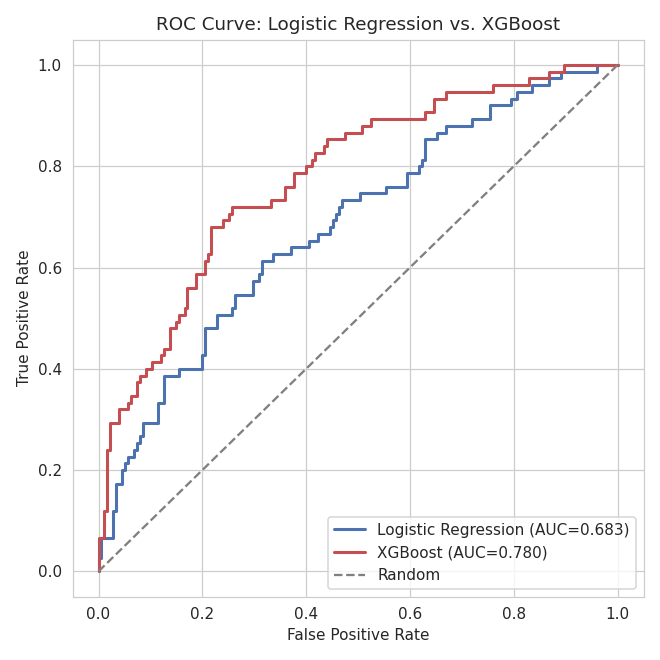

In [14]:
plot_roc_overlay(y_test, {'Logistic Regression': y_score_lr, 'XGBoost': y_score_xgb})
display(Image('reports/figures/05_roc_overlay.png'))

XGBoost clearly outperforms the Logistic Regression baseline on every
discrimination metric (AUC, KS, Gini). This is expected — XGBoost can capture
the non-linear and non-monotonic patterns (e.g. in `Checking account` and
`Credit amount`) that the linear model cannot. The trade-off, discussed fully
in the validation report, is interpretability: every LR coefficient has a
direct, auditable sign and magnitude; XGBoost's decision surface does not, and
would need SHAP or similar post-hoc explanation to be defensible to a
regulator.

## 7. Stability checks: PSI

In [15]:
from validation import psi_table, psi

feature_cols = ['Age', 'Credit amount', 'Duration', 'Saving accounts_ord', 'Checking account_ord']
psi_feat = psi_table(X_train, X_test, cols=feature_cols)

psi_scores = pd.DataFrame([
    {'feature': 'LR_score', 'PSI': psi(lr_model.predict_proba(scaler.transform(X_train))[:,1], y_score_lr)},
    {'feature': 'XGB_score', 'PSI': psi(xgb_model.predict_proba(X_train)[:,1], y_score_xgb)},
])
pd.concat([psi_feat, psi_scores], ignore_index=True).sort_values('PSI', ascending=False)

,feature,PSI
0,Age,0.068095
6,XGB_score,0.041291
1,Credit amount,0.030908
2,Saving accounts_ord,0.026838
5,LR_score,0.024886
3,Duration,0.008805
4,Checking account_ord,0.000044


All PSI values are well under the 0.1 'no significant shift' threshold.
**Caveat**: because train/test here is a random split of the same cross-sectional
sample (not a true out-of-time sample), low PSI is close to guaranteed by
construction and is weak evidence of real-world temporal stability. A proper
stability assessment would need a genuinely out-of-time holdout, which this
dataset does not provide (no date field). Flagged as a limitation.

## 8. Calibration (Logistic Regression)

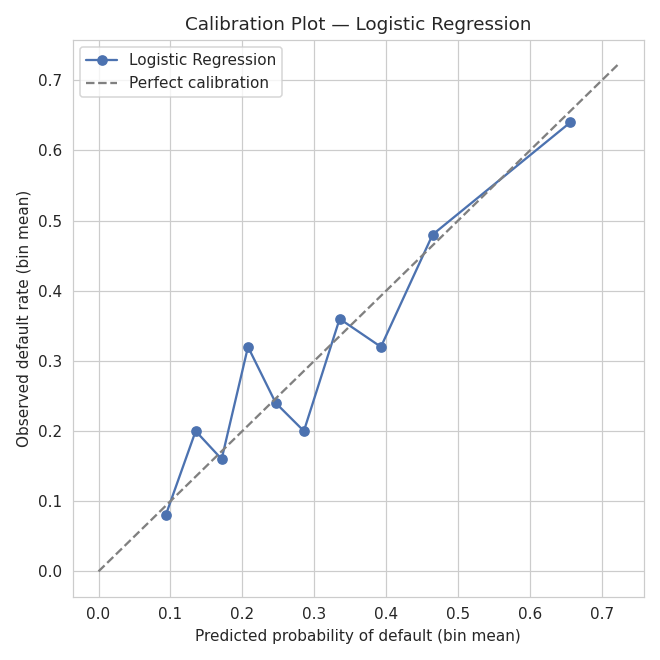

,predicted,observed,n
0,0.093,0.08,25
1,0.135,0.20,25
2,0.171,0.16,25
3,0.208,0.32,25
4,0.246,0.24,25
5,0.286,0.20,25
6,0.335,0.36,25
7,0.393,0.32,25
8,0.465,0.48,25
9,0.656,0.64,25


In [16]:
from validation import plot_calibration
calib = plot_calibration(y_test, y_score_lr)
display(Image('reports/figures/06_calibration_lr.png'))
calib.round(3)

Calibration is reasonably good given the small test set (n=250, ~25 per bin) — predicted and observed rates track closely with expected sampling noise in the middle bins.

## Summary

See `reports/validation_report.md` for the full independent validation write-up,
including the final model recommendation, all limitations, and the
interpretability-vs-performance trade-off discussion.